 saved plot


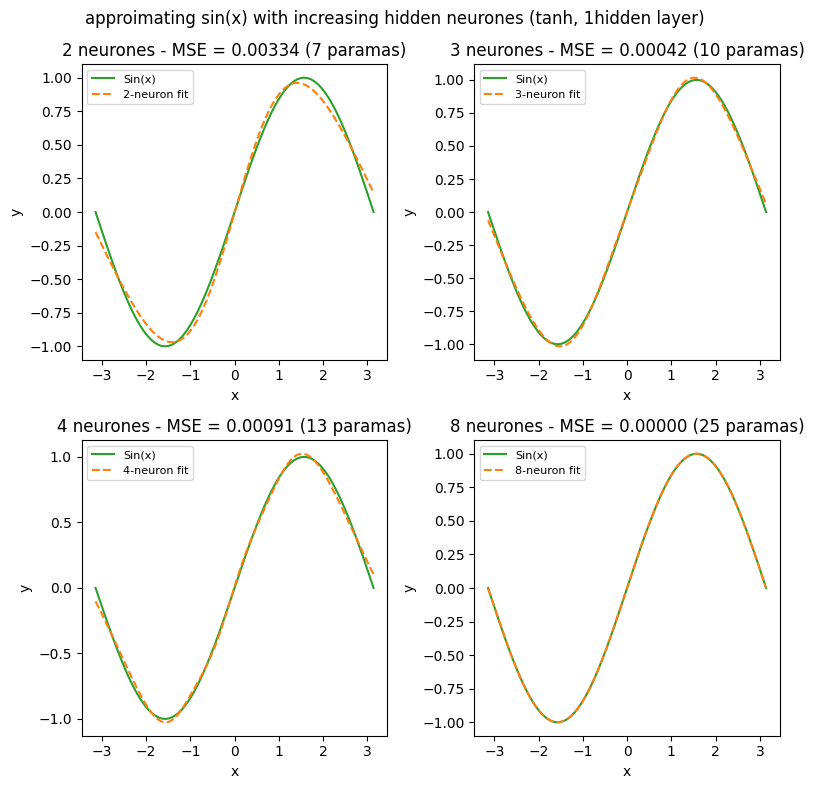

In [13]:
import  numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class small_net(nn.Module):
    def __init__(self,n_hidden):
      super().__init__()
      self.hidden = nn.Linear(1,n_hidden)
      self.activation = nn.Tanh()
      self.output = nn.Linear(n_hidden,1)

    def forward(self,x): # Forward sum

      z = self.hidden(x)
      a = self.activation(z)
      out = self.output(a)
      return out

def train_NN(n_hidden, x_train, y_train, epochs=3000, lr=0.01, seed=0 ):
      torch.manual_seed(seed) # read the summary at end to understand what this does
      model= small_net(n_hidden)
      optimizer = torch.optim.Adam(model.parameters(), lr=lr)
      loss_func = nn.MSELoss()

      for _ in range(epochs):
        optimizer.zero_grad()
        y_prediction = model(x_train)
        loss = loss_func(y_prediction, y_train)
        loss.backward()
        optimizer.step()


      final_mse = loss.item()
      return model , final_mse


def main():
  x_in = np.linspace(-np.pi,np.pi,200).reshape(-1,1)
  y_in = np.sin(x_in)


  x_train = torch.tensor(x_in, dtype=torch.float32)
  y_train = torch.tensor(y_in, dtype=torch.float32)

  neuron_counts = [2,3,4,8]
  results = {}

  fig, axes = plt.subplots(2,2,figsize=(8,8))
  axes = axes.flatten()

  for ax, n_hidden in zip(axes,neuron_counts):
    model, mse = train_NN(n_hidden, x_train, y_train)
    results[n_hidden] = mse

    with torch.no_grad():
      y_pred = model(x_train).numpy()


    n_params=sum(p.numel() for p in model.parameters())

    ax.plot(x_in, y_in, label= "Sin(x)", color ="tab:green")
    ax.plot(x_in,y_pred, label = f"{n_hidden}-neuron fit",
            linestyle="--", color="tab:orange")
    ax.set_title (f"{n_hidden} neurones - MSE = {mse:.5f} ({n_params} paramas)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)

  fig.suptitle("approimating sin(x) with increasing hidden neurones (tanh, 1hidden layer)")
  fig.tight_layout()
  fig.savefig("Sin_approximation.png")
  print(" saved plot")




if __name__ == "__main__":
  main()



